In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class CarEnv:

    def __init__(
        self,
        reward_type="B",
        force_noise_ratio=0.0
    ):
        self.m = 1000.0
        self.dt = 0.1
        self.force_scale = 1000.0
        self.target = 10.0

        self.reward_type = reward_type
        self.force_noise_ratio = force_noise_ratio

        self.reset()

    def reset(self):
        self.x = 0.0
        self.v = 0.0
        self.time = 0.0

        self.previous_distance = abs(self.target - self.x)
        self.current_distance = self.previous_distance
        self.actual_force = 0.0

        return np.array([self.x, self.v], dtype=float)

    def step(self, action):
        self.previous_distance = abs(self.target - self.x)

        commanded_force = action * self.force_scale

        force_noise_std = (
            self.force_noise_ratio * self.force_scale
        )

        force_noise = np.random.normal(
            loc=0.0,
            scale=force_noise_std
        )

        self.actual_force = commanded_force + force_noise

        acceleration = self.actual_force / self.m

        self.v = self.v + acceleration * self.dt
        self.x = self.x + self.v * self.dt
        self.time += self.dt

        self.current_distance = abs(self.target - self.x)

        done = self.x >= self.target

        if self.reward_type == "A":
            reward = -self.current_distance

        elif self.reward_type == "B":
            if self.current_distance < self.previous_distance:
                reward = 1.0
            elif self.current_distance > self.previous_distance:
                reward = -1.0
            else:
                reward = 0.0

        elif self.reward_type == "C":
            reward = 100.0 if done else -1.0

        elif self.reward_type == "D":
            reward = (
                -self.current_distance
                + (
                    1.0
                    if self.current_distance
                    < self.previous_distance
                    else -1.0
                )
            )

            if done:
                reward += 100.0

        else:
            raise ValueError(
                f"Unknown reward type: {self.reward_type}"
            )

        next_state = np.array(
            [self.x, self.v],
            dtype=float
        )

        return next_state, reward, done

In [3]:
actions_3 = np.array([-1.0, 0.0, 1.0])

actions_11 = np.linspace(
    -1.0,
    1.0,
    11
)

actions = actions_11

In [4]:
def discretize_state(state):
    x, v = state

    discrete_x = round(x, 1)
    discrete_v = round(v, 1)

    return discrete_x, discrete_v


def get_q_values(Q, state, actions):
    if state not in Q:
        Q[state] = np.zeros(
            len(actions),
            dtype=float
        )

    return Q[state]


def select_action(
    Q,
    state,
    epsilon,
    actions
):
    if np.random.random() < epsilon:
        action_index = np.random.randint(
            len(actions)
        )
    else:
        q_values = get_q_values(
            Q,
            state,
            actions
        )

        max_indices = np.flatnonzero(
            q_values == np.max(q_values)
        )

        action_index = np.random.choice(
            max_indices
        )

    action = actions[action_index]

    return action, action_index

In [5]:
def get_epsilon(
    strategy,
    episode,
    episodes
):
    if strategy == "constant_01":
        return 0.1

    elif strategy == "constant_1":
        return 1.0

    elif strategy == "sudden_drop":
        if episode < episodes // 2:
            return 1.0
        else:
            return 0.1

    elif strategy == "decay":
        epsilon_start = 1.0
        epsilon_min = 0.1
        decay_rate = 0.995

        epsilon = (
            epsilon_start
            * (decay_rate ** episode)
        )

        return max(
            epsilon_min,
            epsilon
        )

    else:
        raise ValueError(
            f"Unknown epsilon strategy: {strategy}"
        )

In [6]:
def update_q_learning(
    Q,
    state,
    action_index,
    reward,
    next_state,
    alpha,
    gamma,
    actions,
    done
):
    q_values = get_q_values(
        Q,
        state,
        actions
    )

    if done:
        target = reward
    else:
        next_q_values = get_q_values(
            Q,
            next_state,
            actions
        )

        target = (
            reward
            + gamma * np.max(next_q_values)
        )

    q_values[action_index] += alpha * (
        target - q_values[action_index]
    )

In [7]:
def train_q_learning(
    reward_type,
    strategy,
    actions,
    force_noise_ratio=0.0,
    episodes=500,
    max_steps=200,
    alpha=0.1,
    gamma=0.99
):
    env = CarEnv(
        reward_type=reward_type,
        force_noise_ratio=force_noise_ratio
    )

    Q = {}

    episode_rewards = []
    success_log = []
    epsilon_log = []

    for episode in range(episodes):
        epsilon = get_epsilon(
            strategy,
            episode,
            episodes
        )

        state = env.reset()
        state = discretize_state(state)

        total_reward = 0.0
        done = False

        for step in range(max_steps):
            action, action_index = select_action(
                Q,
                state,
                epsilon,
                actions
            )

            next_state, reward, done = env.step(
                action
            )

            next_state = discretize_state(
                next_state
            )

            update_q_learning(
                Q=Q,
                state=state,
                action_index=action_index,
                reward=reward,
                next_state=next_state,
                alpha=alpha,
                gamma=gamma,
                actions=actions,
                done=done
            )

            total_reward += reward
            state = next_state

            if done:
                break

        episode_rewards.append(total_reward)
        success_log.append(done)
        epsilon_log.append(epsilon)

    return (
        Q,
        episode_rewards,
        success_log,
        epsilon_log
    )

In [8]:
def update_sarsa(
    Q,
    state,
    action_index,
    reward,
    next_state,
    next_action_index,
    alpha,
    gamma,
    actions,
    done
):
    q_values = get_q_values(
        Q,
        state,
        actions
    )

    if done:
        target = reward
    else:
        next_q_values = get_q_values(
            Q,
            next_state,
            actions
        )

        target = (
            reward
            + gamma
            * next_q_values[next_action_index]
        )

    q_values[action_index] += alpha * (
        target - q_values[action_index]
    )

In [9]:
def train_sarsa(
    reward_type,
    strategy,
    actions,
    force_noise_ratio=0.0,
    episodes=500,
    max_steps=200,
    alpha=0.1,
    gamma=0.99
):
    env = CarEnv(
        reward_type=reward_type,
        force_noise_ratio=force_noise_ratio
    )

    Q = {}

    episode_rewards = []
    success_log = []
    epsilon_log = []

    for episode in range(episodes):
        epsilon = get_epsilon(
            strategy,
            episode,
            episodes
        )

        state = env.reset()
        state = discretize_state(state)

        action, action_index = select_action(
            Q,
            state,
            epsilon,
            actions
        )

        total_reward = 0.0
        done = False

        for step in range(max_steps):
            next_state, reward, done = env.step(
                action
            )

            next_state = discretize_state(
                next_state
            )

            total_reward += reward

            if done:
                next_action = None
                next_action_index = None

            else:
                (
                    next_action,
                    next_action_index
                ) = select_action(
                    Q,
                    next_state,
                    epsilon,
                    actions
                )

            update_sarsa(
                Q=Q,
                state=state,
                action_index=action_index,
                reward=reward,
                next_state=next_state,
                next_action_index=next_action_index,
                alpha=alpha,
                gamma=gamma,
                actions=actions,
                done=done
            )

            if done:
                break

            state = next_state
            action = next_action
            action_index = next_action_index

        episode_rewards.append(total_reward)
        success_log.append(done)
        epsilon_log.append(epsilon)

    return (
        Q,
        episode_rewards,
        success_log,
        epsilon_log
    )

In [10]:
def train_monte_carlo(
    reward_type,
    strategy,
    actions,
    force_noise_ratio=0.0,
    episodes=500,
    max_steps=200,
    gamma=0.99
):
    env = CarEnv(
        reward_type=reward_type,
        force_noise_ratio=force_noise_ratio
    )

    Q = {}
    returns_sum = {}
    returns_count = {}

    episode_rewards = []
    success_log = []
    epsilon_log = []

    for episode in range(episodes):
        epsilon = get_epsilon(
            strategy,
            episode,
            episodes
        )

        state = env.reset()
        state = discretize_state(state)

        episode_data = []

        total_reward = 0.0
        done = False

        for step in range(max_steps):
            action, action_index = select_action(
                Q,
                state,
                epsilon,
                actions
            )

            next_state, reward, done = env.step(
                action
            )

            next_state = discretize_state(
                next_state
            )

            episode_data.append(
                (
                    state,
                    action_index,
                    reward
                )
            )

            total_reward += reward
            state = next_state

            if done:
                break

        G = 0.0
        returns = []

        for state, action_index, reward in reversed(
            episode_data
        ):
            G = reward + gamma * G

            returns.append(
                (
                    state,
                    action_index,
                    G
                )
            )

        returns.reverse()

        visited_state_actions = set()

        for state, action_index, G in returns:
            state_action = (
                state,
                action_index
            )

            if state_action in visited_state_actions:
                continue

            visited_state_actions.add(
                state_action
            )

            if state_action not in returns_sum:
                returns_sum[state_action] = 0.0
                returns_count[state_action] = 0

            returns_sum[state_action] += G
            returns_count[state_action] += 1

            q_values = get_q_values(
                Q,
                state,
                actions
            )

            q_values[action_index] = (
                returns_sum[state_action]
                / returns_count[state_action]
            )

        episode_rewards.append(total_reward)
        success_log.append(done)
        epsilon_log.append(epsilon)

    return (
        Q,
        episode_rewards,
        success_log,
        epsilon_log
    )

In [11]:
def evaluate_policy(
    Q,
    reward_type,
    actions,
    force_noise_ratio=0.0,
    max_steps=200
):
    env = CarEnv(
        reward_type=reward_type,
        force_noise_ratio=force_noise_ratio
    )

    state = env.reset()

    times = []
    positions = []
    velocities = []
    selected_actions = []
    rewards = []
    actual_forces = []

    total_reward = 0.0
    done = False

    for step in range(max_steps):
        discrete_state = discretize_state(
            state
        )

        q_values = get_q_values(
            Q,
            discrete_state,
            actions
        )

        max_indices = np.flatnonzero(
            q_values == np.max(q_values)
        )

        action_index = np.random.choice(
            max_indices
        )

        action = actions[action_index]

        next_state, reward, done = env.step(
            action
        )

        total_reward += reward

        times.append(env.time)
        positions.append(next_state[0])
        velocities.append(next_state[1])
        selected_actions.append(action)
        rewards.append(reward)
        actual_forces.append(env.actual_force)

        state = next_state

        if done:
            break

    trajectory = {
        "times": times,
        "positions": positions,
        "velocities": velocities,
        "actions": selected_actions,
        "rewards": rewards,
        "actual_forces": actual_forces,
        "total_reward": total_reward,
        "done": done
    }

    return trajectory

In [12]:
def evaluate_policy_multiple(
    Q,
    reward_type,
    actions,
    force_noise_ratio=0.0,
    evaluation_episodes=100,
    max_steps=200
):
    success_results = []
    step_results = []
    reward_results = []
    overshoot_results = []
    final_velocity_results = []

    trajectories = []

    for episode in range(evaluation_episodes):
        trajectory = evaluate_policy(
            Q=Q,
            reward_type=reward_type,
            actions=actions,
            force_noise_ratio=force_noise_ratio,
            max_steps=max_steps
        )

        trajectories.append(trajectory)

        success = trajectory["done"]
        steps = len(trajectory["actions"])

        success_results.append(success)
        step_results.append(steps)
        reward_results.append(
            trajectory["total_reward"]
        )

        if len(trajectory["positions"]) > 0:
            final_x = trajectory["positions"][-1]
            final_v = trajectory["velocities"][-1]

            overshoot = final_x - 10.0
        else:
            final_v = np.nan
            overshoot = np.nan

        overshoot_results.append(overshoot)
        final_velocity_results.append(final_v)

    success_results = np.asarray(
        success_results,
        dtype=float
    )

    step_results = np.asarray(
        step_results,
        dtype=float
    )

    reward_results = np.asarray(
        reward_results,
        dtype=float
    )

    overshoot_results = np.asarray(
        overshoot_results,
        dtype=float
    )

    final_velocity_results = np.asarray(
        final_velocity_results,
        dtype=float
    )

    successful_mask = (
        success_results == 1
    )

    if np.any(successful_mask):
        mean_success_steps = np.mean(
            step_results[successful_mask]
        )

        mean_success_overshoot = np.mean(
            overshoot_results[successful_mask]
        )

        mean_success_final_velocity = np.mean(
            final_velocity_results[
                successful_mask
            ]
        )

    else:
        mean_success_steps = np.nan
        mean_success_overshoot = np.nan
        mean_success_final_velocity = np.nan

    results = {
        "success_rate": np.mean(
            success_results
        ),
        "mean_steps_all": np.mean(
            step_results
        ),
        "mean_steps_success": mean_success_steps,
        "mean_reward": np.mean(
            reward_results
        ),
        "mean_overshoot_success": (
            mean_success_overshoot
        ),
        "mean_final_velocity_success": (
            mean_success_final_velocity
        ),
        "trajectories": trajectories
    }

    return results

In [13]:
reward_type = "B"
strategy = "constant_01"
actions = actions_11

force_noise_ratio = 0.3

episodes = 500
max_steps = 200

alpha = 0.1
gamma = 0.99

In [14]:
(
    Q_q_learning,
    q_learning_rewards,
    q_learning_success_log,
    q_learning_epsilon_log
) = train_q_learning(
    reward_type=reward_type,
    strategy=strategy,
    actions=actions,
    force_noise_ratio=force_noise_ratio,
    episodes=episodes,
    max_steps=max_steps,
    alpha=alpha,
    gamma=gamma
)

print("Q-learning completed")

Q-learning completed


In [15]:
(
    Q_sarsa,
    sarsa_rewards,
    sarsa_success_log,
    sarsa_epsilon_log
) = train_sarsa(
    reward_type=reward_type,
    strategy=strategy,
    actions=actions,
    force_noise_ratio=force_noise_ratio,
    episodes=episodes,
    max_steps=max_steps,
    alpha=alpha,
    gamma=gamma
)

print("SARSA completed")

SARSA completed


In [16]:
(
    Q_monte_carlo,
    monte_carlo_rewards,
    monte_carlo_success_log,
    monte_carlo_epsilon_log
) = train_monte_carlo(
    reward_type=reward_type,
    strategy=strategy,
    actions=actions,
    force_noise_ratio=force_noise_ratio,
    episodes=episodes,
    max_steps=max_steps,
    gamma=gamma
)

print("Monte Carlo completed")

Monte Carlo completed


In [17]:
def moving_average(values, window=50):
    values = np.asarray(
        values,
        dtype=float
    )

    if len(values) < window:
        return values

    weights = np.ones(window) / window

    return np.convolve(
        values,
        weights,
        mode="valid"
    )

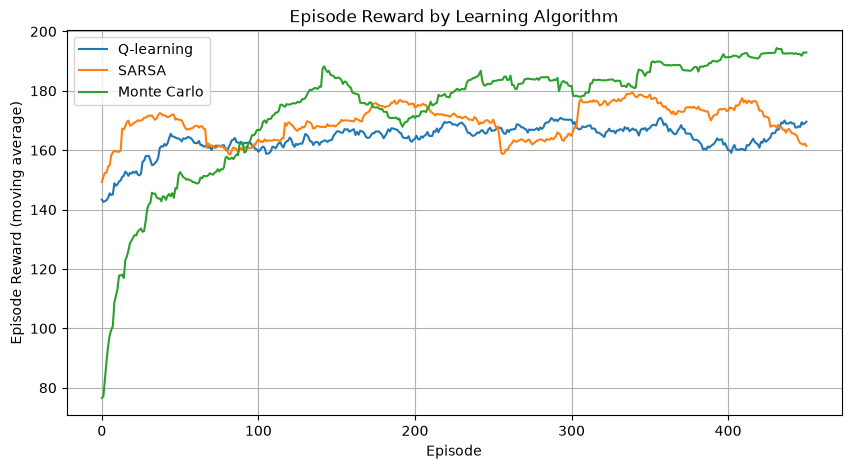

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    moving_average(
        q_learning_rewards,
        window=50
    ),
    label="Q-learning"
)

plt.plot(
    moving_average(
        sarsa_rewards,
        window=50
    ),
    label="SARSA"
)

plt.plot(
    moving_average(
        monte_carlo_rewards,
        window=50
    ),
    label="Monte Carlo"
)

plt.xlabel("Episode")
plt.ylabel("Episode Reward (moving average)")
plt.title(
    "Episode Reward by Learning Algorithm"
)
plt.legend()
plt.grid(True)
plt.show()

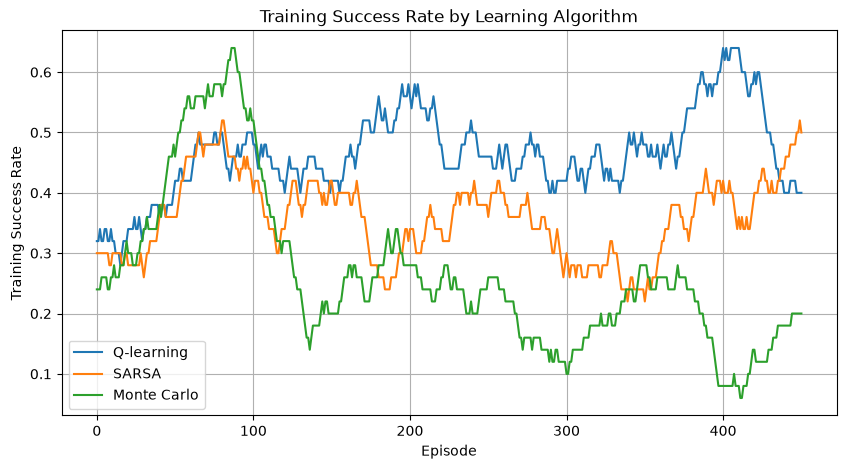

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    moving_average(
        q_learning_success_log,
        window=50
    ),
    label="Q-learning"
)

plt.plot(
    moving_average(
        sarsa_success_log,
        window=50
    ),
    label="SARSA"
)

plt.plot(
    moving_average(
        monte_carlo_success_log,
        window=50
    ),
    label="Monte Carlo"
)

plt.xlabel("Episode")
plt.ylabel("Training Success Rate")
plt.title(
    "Training Success Rate by Learning Algorithm"
)
plt.legend()
plt.grid(True)
plt.show()

In [20]:
evaluation_episodes = 100

q_learning_evaluation = (
    evaluate_policy_multiple(
        Q=Q_q_learning,
        reward_type=reward_type,
        actions=actions,
        force_noise_ratio=force_noise_ratio,
        evaluation_episodes=evaluation_episodes,
        max_steps=max_steps
    )
)

sarsa_evaluation = (
    evaluate_policy_multiple(
        Q=Q_sarsa,
        reward_type=reward_type,
        actions=actions,
        force_noise_ratio=force_noise_ratio,
        evaluation_episodes=evaluation_episodes,
        max_steps=max_steps
    )
)

monte_carlo_evaluation = (
    evaluate_policy_multiple(
        Q=Q_monte_carlo,
        reward_type=reward_type,
        actions=actions,
        force_noise_ratio=force_noise_ratio,
        evaluation_episodes=evaluation_episodes,
        max_steps=max_steps
    )
)

In [21]:
evaluation_results = {
    "Q-learning": q_learning_evaluation,
    "SARSA": sarsa_evaluation,
    "Monte Carlo": monte_carlo_evaluation
}

Q_tables = {
    "Q-learning": Q_q_learning,
    "SARSA": Q_sarsa,
    "Monte Carlo": Q_monte_carlo
}

for algorithm, result in evaluation_results.items():
    print(f"\n{algorithm}")
    print(
        f"Evaluation success rate: "
        f"{result['success_rate']:.2f}"
    )
    print(
        f"Mean evaluation reward: "
        f"{result['mean_reward']:.2f}"
    )
    print(
        f"Mean steps (successful episodes): "
        f"{result['mean_steps_success']:.2f}"
    )
    print(
        f"Mean overshoot (successful episodes): "
        f"{result['mean_overshoot_success']:.4f}"
    )
    print(
        f"Mean final velocity "
        f"(successful episodes): "
        f"{result['mean_final_velocity_success']:.4f}"
    )
    print(
        f"Q states: "
        f"{len(Q_tables[algorithm])}"
    )


Q-learning
Evaluation success rate: 0.38
Mean evaluation reward: 169.56
Mean steps (successful episodes): 151.68
Mean overshoot (successful episodes): 0.0580
Mean final velocity (successful episodes): 1.1490
Q states: 2055

SARSA
Evaluation success rate: 0.42
Mean evaluation reward: 175.70
Mean steps (successful episodes): 159.52
Mean overshoot (successful episodes): 0.0663
Mean final velocity (successful episodes): 1.1514
Q states: 2286

Monte Carlo
Evaluation success rate: 0.10
Mean evaluation reward: 196.13
Mean steps (successful episodes): 188.10
Mean overshoot (successful episodes): 0.0209
Mean final velocity (successful episodes): 0.5402
Q states: 2849


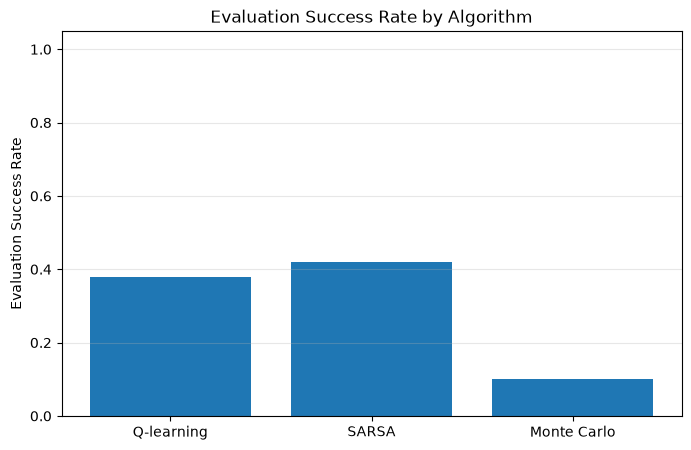

In [22]:
algorithm_names = list(
    evaluation_results.keys()
)

success_rates = [
    evaluation_results[name]["success_rate"]
    for name in algorithm_names
]

plt.figure(figsize=(8, 5))

plt.bar(
    algorithm_names,
    success_rates
)

plt.ylim(0, 1.05)
plt.ylabel("Evaluation Success Rate")
plt.title(
    "Evaluation Success Rate by Algorithm"
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.show()

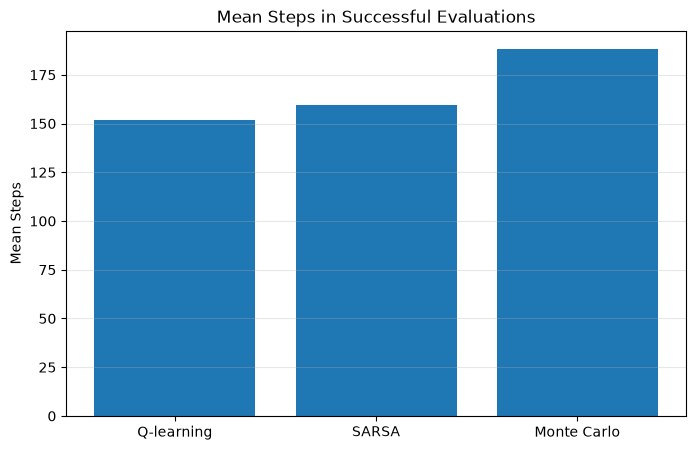

In [23]:
mean_steps = [
    evaluation_results[name][
        "mean_steps_success"
    ]
    for name in algorithm_names
]

plt.figure(figsize=(8, 5))

plt.bar(
    algorithm_names,
    mean_steps
)

plt.ylabel("Mean Steps")
plt.title(
    "Mean Steps in Successful Evaluations"
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.show()

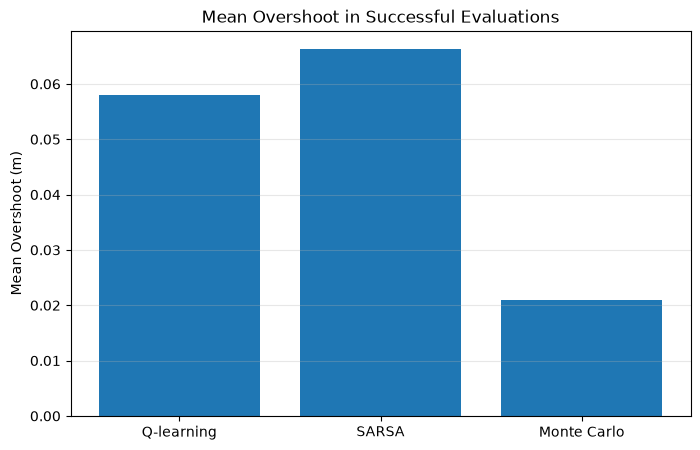

In [24]:
mean_overshoots = [
    evaluation_results[name][
        "mean_overshoot_success"
    ]
    for name in algorithm_names
]

plt.figure(figsize=(8, 5))

plt.bar(
    algorithm_names,
    mean_overshoots
)

plt.ylabel("Mean Overshoot (m)")
plt.title(
    "Mean Overshoot in Successful Evaluations"
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.show()

In [25]:
representative_trajectories = {}

for algorithm, Q in Q_tables.items():
    representative_trajectories[algorithm] = (
        evaluate_policy(
            Q=Q,
            reward_type=reward_type,
            actions=actions,
            force_noise_ratio=force_noise_ratio,
            max_steps=max_steps
        )
    )

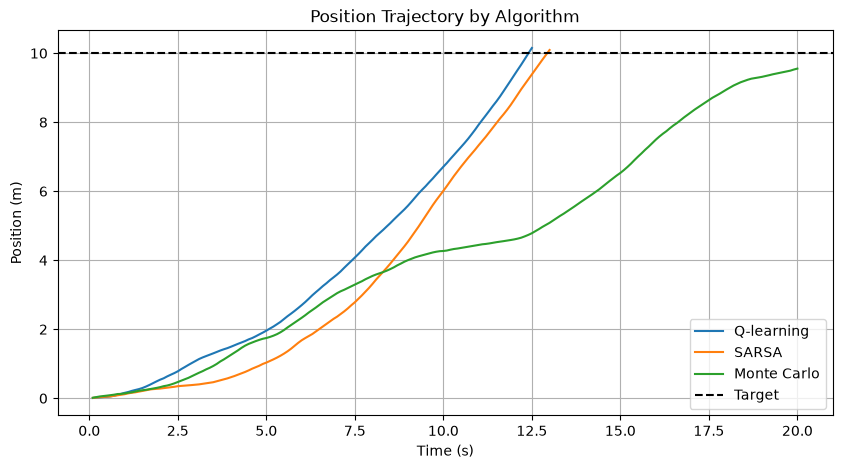

In [26]:
plt.figure(figsize=(10, 5))

for algorithm, trajectory in (
    representative_trajectories.items()
):
    plt.plot(
        trajectory["times"],
        trajectory["positions"],
        label=algorithm
    )

plt.axhline(
    y=10.0,
    color="black",
    linestyle="--",
    label="Target"
)

plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title(
    "Position Trajectory by Algorithm"
)
plt.legend()
plt.grid(True)
plt.show()

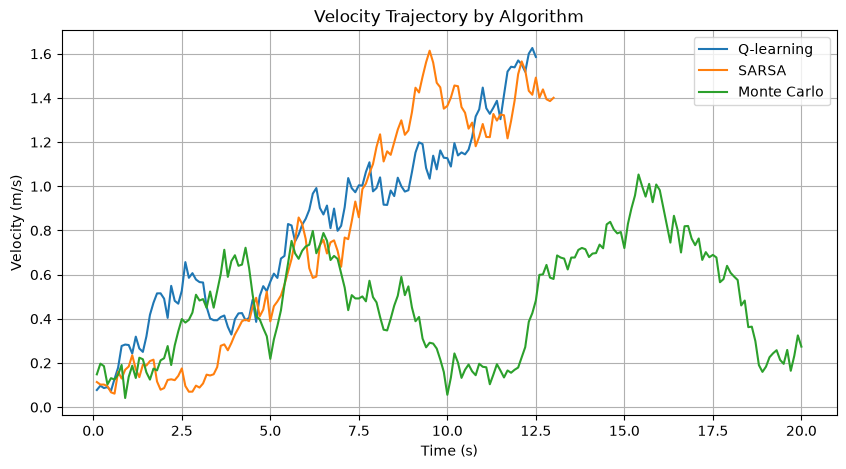

In [27]:
plt.figure(figsize=(10, 5))

for algorithm, trajectory in (
    representative_trajectories.items()
):
    plt.plot(
        trajectory["times"],
        trajectory["velocities"],
        label=algorithm
    )

plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title(
    "Velocity Trajectory by Algorithm"
)
plt.legend()
plt.grid(True)
plt.show()

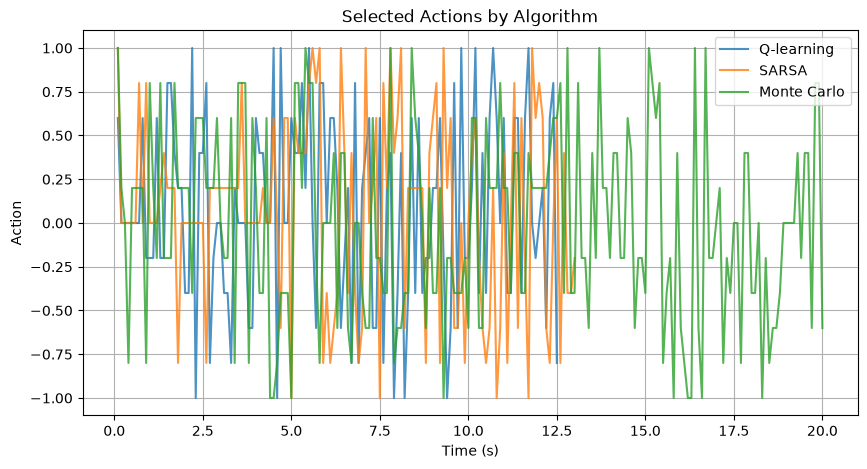

In [28]:
plt.figure(figsize=(10, 5))

for algorithm, trajectory in (
    representative_trajectories.items()
):
    plt.plot(
        trajectory["times"],
        trajectory["actions"],
        label=algorithm,
        alpha=0.8
    )

plt.xlabel("Time (s)")
plt.ylabel("Action")
plt.title(
    "Selected Actions by Algorithm"
)
plt.legend()
plt.grid(True)
plt.show()

In [29]:
print(
    f"Experiment condition\n"
    f"Reward type: {reward_type}\n"
    f"Epsilon strategy: {strategy}\n"
    f"Number of actions: {len(actions)}\n"
    f"Force noise ratio: {force_noise_ratio}\n"
    f"Training episodes: {episodes}\n"
    f"Evaluation episodes: {evaluation_episodes}"
)

for algorithm, result in evaluation_results.items():
    print(
        f"\n{algorithm} | "
        f"success={result['success_rate']:.2f} | "
        f"steps={result['mean_steps_success']:.2f} | "
        f"overshoot="
        f"{result['mean_overshoot_success']:.4f} | "
        f"reward={result['mean_reward']:.2f}"
    )

Experiment condition
Reward type: B
Epsilon strategy: constant_01
Number of actions: 11
Force noise ratio: 0.3
Training episodes: 500
Evaluation episodes: 100

Q-learning | success=0.38 | steps=151.68 | overshoot=0.0580 | reward=169.56

SARSA | success=0.42 | steps=159.52 | overshoot=0.0663 | reward=175.70

Monte Carlo | success=0.10 | steps=188.10 | overshoot=0.0209 | reward=196.13
